In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)




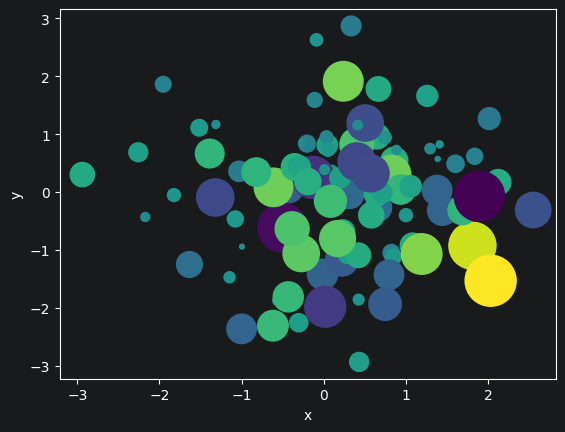

In [2]:

# Generate 100 random data points along 3 dimensions
x, y, scale = np.random.randn(3, 100)
fig, ax = plt.subplots()

# Map each onto a scatterplot we'll create with Matplotlib
ax.scatter(x=x, y=y, c=scale, s=np.abs(scale) * 500)

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()
ax.set(title="Some random data, created with JupyterLab!")



# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
df=sns.load_dataset('titanic')
df=df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     784 non-null    int64   
 1   pclass       784 non-null    int64   
 2   sex          784 non-null    object  
 3   age          678 non-null    float64 
 4   sibsp        784 non-null    int64   
 5   parch        784 non-null    int64   
 6   fare         784 non-null    float64 
 7   embarked     782 non-null    object  
 8   class        784 non-null    category
 9   who          784 non-null    object  
 10  adult_male   784 non-null    bool    
 11  deck         202 non-null    category
 12  embark_town  782 non-null    object  
 13  alive        784 non-null    object  
 14  alone        784 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 77.0+ KB


In [3]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  784.000000  784.000000  678.000000  784.000000  784.000000  784.000000
mean     0.411990    2.243622   29.869351    0.522959    0.415816   34.711740
std      0.492507    0.855056   14.759076    0.986231    0.836922   52.160151
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    1.000000   20.000000    0.000000    0.000000    8.050000
50%      0.000000    3.000000   28.250000    0.000000    0.000000   15.900000
75%      1.000000    3.000000   39.000000    1.000000    1.000000   34.109350
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [5]:
# df.shape
df.isnull().sum()


survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64

In [13]:
print(df.isnull().sum())
print(df.to_string())
df=df.drop(columns=['deck'])



survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64
     survived  pclass     sex    age  sibsp  parch      fare embarked   class    who  adult_male deck  embark_town alive  alone
0           0       3    male  22.00      1      0    7.2500        S   Third    man        True  NaN  Southampton    no  False
1           1       1  female  38.00      1      0   71.2833        C   First  woman       False    C    Cherbourg   yes  False
2           1       3  female  26.00      0      0    7.9250        S   Third  woman       False  NaN  Southampton   yes   True
3           1       1  female  35.00      1      0   53.1000        S   First  woman       False    C  Southampton   yes  False
4           0       3    male  35.00      0      0    8.0500  

In [14]:
print(df.isnull().sum())
print(df.to_string())

survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64
     survived  pclass     sex    age  sibsp  parch      fare embarked   class    who  adult_male  embark_town alive  alone
0           0       3    male  22.00      1      0    7.2500        S   Third    man        True  Southampton    no  False
1           1       1  female  38.00      1      0   71.2833        C   First  woman       False    Cherbourg   yes  False
2           1       3  female  26.00      0      0    7.9250        S   Third  woman       False  Southampton   yes   True
3           1       1  female  35.00      1      0   53.1000        S   First  woman       False  Southampton   yes  False
4           0       3    male  35.00      0      0    8.0500        S   Third    man        True  Southamp

In [15]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64

In [25]:
df['age']=df['age'].fillna(df['age'].median())




In [26]:
print(df.to_string())

     survived  pclass     sex    age  sibsp  parch      fare embarked   class    who  adult_male  embark_town alive  alone
0           0       3    male  22.00      1      0    7.2500        S   Third    man        True  Southampton    no  False
1           1       1  female  38.00      1      0   71.2833        C   First  woman       False    Cherbourg   yes  False
2           1       3  female  26.00      0      0    7.9250        S   Third  woman       False  Southampton   yes   True
3           1       1  female  35.00      1      0   53.1000        S   First  woman       False  Southampton   yes  False
4           0       3    male  35.00      0      0    8.0500        S   Third    man        True  Southampton    no   True
5           0       3    male  28.25      0      0    8.4583        Q   Third    man        True   Queenstown    no   True
6           0       1    male  54.00      0      0   51.8625        S   First    man        True  Southampton    no   True
7           0   

In [27]:
df=df.drop(columns=['embark_town'])
print(df.head())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male alive  alone  
0    man        True    no  False  
1  woman       False   yes  False  
2  woman       False   yes   True  
3  woman       False   yes  False  
4    man        True    no   True  


In [28]:
pd.crosstab(df['pclass'], df['class'])

class,First,Second,Third
pclass,,,
1,214,0,0
2,0,165,0
3,0,0,405


>pclass==class
 \>drop class

In [29]:
df=df.drop(columns=['class'])
print(df.head())


   survived  pclass     sex   age  sibsp  parch     fare embarked    who  \
0         0       3    male  22.0      1      0   7.2500        S    man   
1         1       1  female  38.0      1      0  71.2833        C  woman   
2         1       3  female  26.0      0      0   7.9250        S  woman   
3         1       1  female  35.0      1      0  53.1000        S  woman   
4         0       3    male  35.0      0      0   8.0500        S    man   

   adult_male alive  alone  
0        True    no  False  
1       False   yes  False  
2       False   yes   True  
3       False   yes  False  
4        True    no   True  


In [30]:
pd.crosstab(df['alive'], df['survived'])

survived,0,1
alive,,
no,461,0
yes,0,323


In [ ]:
df=df.drop(columns=['alive'])

In [32]:
print(df.isnull().sum())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
print(df.isnull().sum())


survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      2
who           0
adult_male    0
alone         0
dtype: int64
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
who           0
adult_male    0
alone         0
dtype: int64


In [33]:
df = df.drop(columns=['who', 'adult_male', 'alone'])
print(df.head())
print(df.dtypes)

   survived  pclass     sex   age  sibsp  parch     fare embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S
survived      int64
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
dtype: object


In [34]:
print(df.describe(include='object'))

         sex embarked
count    784      784
unique     2        3
top     male        S
freq     491      570


In [35]:
print(df.describe(include='all'))

          survived      pclass   sex         age       sibsp       parch  \
count   784.000000  784.000000   784  784.000000  784.000000  784.000000   
unique         NaN         NaN     2         NaN         NaN         NaN   
top            NaN         NaN  male         NaN         NaN         NaN   
freq           NaN         NaN   491         NaN         NaN         NaN   
mean      0.411990    2.243622   NaN   29.650408    0.522959    0.415816   
std       0.492507    0.855056   NaN   13.734925    0.986231    0.836922   
min       0.000000    1.000000   NaN    0.420000    0.000000    0.000000   
25%       0.000000    1.000000   NaN   22.000000    0.000000    0.000000   
50%       0.000000    3.000000   NaN   28.250000    0.000000    0.000000   
75%       1.000000    3.000000   NaN   36.000000    1.000000    1.000000   
max       1.000000    3.000000   NaN   80.000000    8.000000    6.000000   

              fare embarked  
count   784.000000      784  
unique         NaN        3

In [36]:
print(df.duplicated().sum())

4


In [37]:
df=df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  780 non-null    int64  
 1   pclass    780 non-null    int64  
 2   sex       780 non-null    object 
 3   age       780 non-null    float64
 4   sibsp     780 non-null    int64  
 5   parch     780 non-null    int64  
 6   fare      780 non-null    float64
 7   embarked  780 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 54.8+ KB


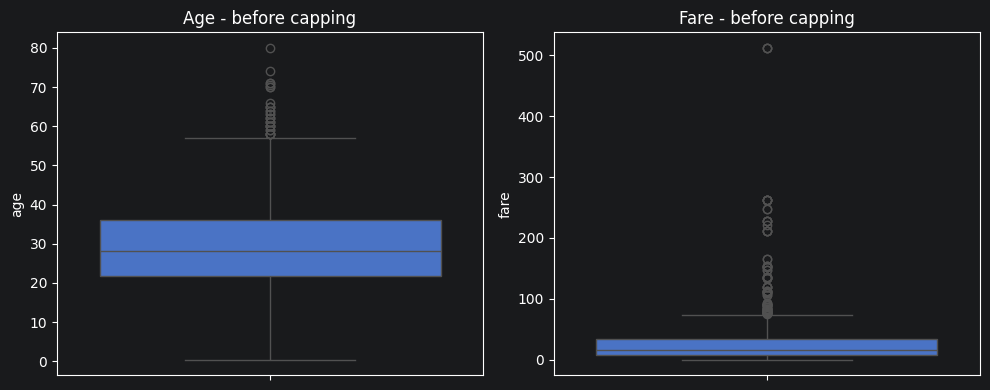

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['age'], ax=axes[0])
axes[0].set_title('Age - before capping')

sns.boxplot(y=df['fare'], ax=axes[1])
axes[1].set_title('Fare - before capping')

plt.tight_layout()
plt.show()

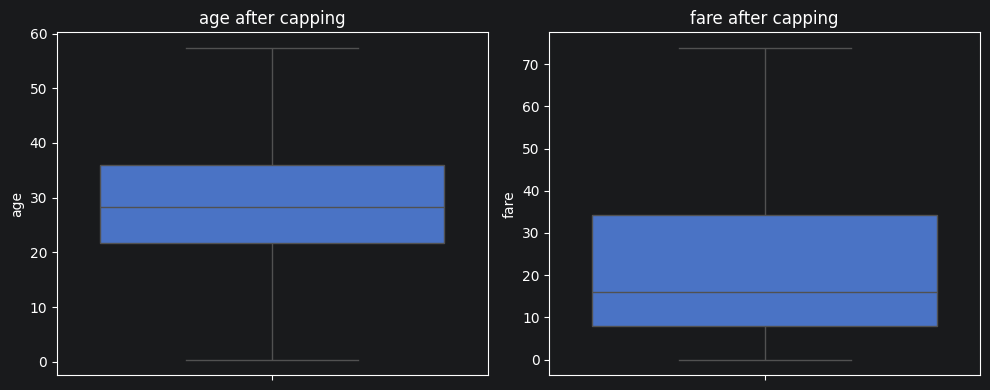

In [39]:
def capoutliers(series, k=1.5):
    q1,q3=series.quantile(0.25),series.quantile(0.75)
    iqr = q3-q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return series.clip(lower, upper)

df['fare']=capoutliers(df['fare'])
df['age']=capoutliers(df['age'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['age'], ax=axes[0])
axes[0].set_title('age after capping')

sns.boxplot(y=df['fare'], ax=axes[1])
axes[1].set_title('fare after capping')


plt.tight_layout()
plt.show()

In [41]:
print(df.to_string())

     survived  pclass     sex     age  sibsp  parch     fare embarked
0           0       3    male  22.000      1      0   7.2500        S
1           1       1  female  38.000      1      0  71.2833        C
2           1       3  female  26.000      0      0   7.9250        S
3           1       1  female  35.000      1      0  53.1000        S
4           0       3    male  35.000      0      0   8.0500        S
5           0       3    male  28.250      0      0   8.4583        Q
6           0       1    male  54.000      0      0  51.8625        S
7           0       3    male   2.000      3      1  21.0750        S
8           1       3  female  27.000      0      2  11.1333        S
9           1       2  female  14.000      1      0  30.0708        C
10          1       3  female   4.000      1      1  16.7000        S
11          1       1  female  57.375      0      0  26.5500        S
12          0       3    male  20.000      0      0   8.0500        S
13          0       

In [42]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)
print(df.head())

   survived  pclass  sex   age  sibsp  parch     fare  embarked_Q  embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True


In [44]:
df.describe()
print(df.dtypes)

survived        int64
pclass          int64
sex             int64
age           float64
sibsp           int64
parch           int64
fare          float64
embarked_Q       bool
embarked_S       bool
dtype: object


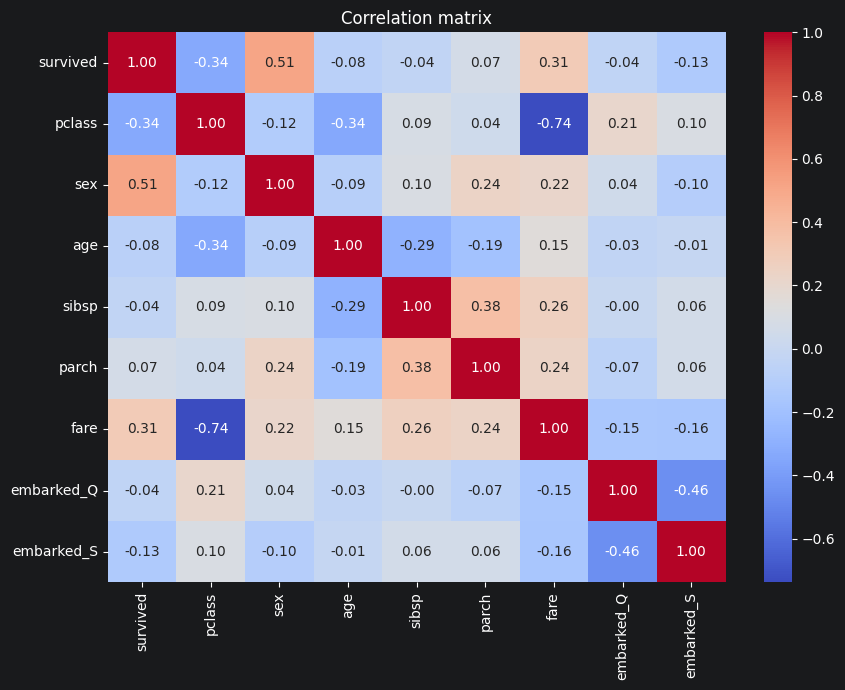

In [45]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

 FEATURE / TARGET SPLIT

In [46]:
X = df.drop(columns=['survived']) #feartuer
y = df['survived'] #target
df.describe()
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    780 non-null    int64  
 1   pclass      780 non-null    int64  
 2   sex         780 non-null    int64  
 3   age         780 non-null    float64
 4   sibsp       780 non-null    int64  
 5   parch       780 non-null    int64  
 6   fare        780 non-null    float64
 7   embarked_Q  780 non-null    bool   
 8   embarked_S  780 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.3 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [47]:
print(df['parch'].value_counts())
print(df['embarked_Q'].value_counts())

parch
0    576
1    114
2     75
5      5
3      5
4      4
6      1
Name: count, dtype: int64
embarked_Q
False    722
True      58
Name: count, dtype: int64


In [48]:
df['embarked_Q'] = df['embarked_Q'].astype(int)
df['embarked_S'] = df['embarked_S'].astype(int)

df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

print(X.dtypes)
print(X.isnull().sum().sum())
print(X.shape, y.shape)
print(df.head())

pclass          int64
sex             int64
age           float64
sibsp           int64
parch           int64
fare          float64
embarked_Q       bool
embarked_S       bool
dtype: object
0
(780, 8) (780,)
   survived  pclass  sex   age  sibsp  parch     fare  embarked_Q  embarked_S  \
0         0       3    0  22.0      1      0   7.2500           0           1   
1         1       1    1  38.0      1      0  71.2833           0           0   
2         1       3    1  26.0      0      0   7.9250           0           1   
3         1       1    1  35.0      1      0  53.1000           0           1   
4         0       3    0  35.0      0      0   8.0500           0           1   

   family_size  is_alone  
0            2         0  
1            2         0  
2            1         1  
3            2         0  
4            1         1  


In [49]:
X = df.drop(columns=['survived'])
y = df['survived']

print(X.dtypes)
print(X.isnull().sum().sum())
print(X.shape, y.shape)

pclass           int64
sex              int64
age            float64
sibsp            int64
parch            int64
fare           float64
embarked_Q       int64
embarked_S       int64
family_size      int64
is_alone         int64
dtype: object
0
(780, 10) (780,)


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(624, 10) (156, 10)


In [51]:
# SCALING-> log(fare), then StandardScaler on all numeric cols
# log1p handles fare == 0 safely (log(0) is undefined)
X_train['fare']=np.log1p(X_train['fare'])
X_test['fare']=np.log1p(X_test['fare'])


num_cols = ['age','sibsp','parch','fare']
scaler=StandardScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])   # fit ONLY on train
X_test[num_cols]=scaler.transform(X_test[num_cols])         # transform test with train's stats

In [53]:
print(X.head())
print(y.head())
print(X_train.head())
print(X_test.head())
print(X_train.isnull().sum())
print(X_test.isnull().sum())
print(X_train.describe())
print(X_test.describe())
print(y.isnull().sum())
print(y_train.describe())
print(y_test.describe())
print(y_test.isnull().sum())
print(y_train.isnull().sum())




   pclass  sex   age  sibsp  parch     fare  embarked_Q  embarked_S  \
0       3    0  22.0      1      0   7.2500           0           1   
1       1    1  38.0      1      0  71.2833           0           0   
2       3    1  26.0      0      0   7.9250           0           1   
3       1    1  35.0      1      0  53.1000           0           1   
4       3    0  35.0      0      0   8.0500           0           1   

   family_size  is_alone  
0            2         0  
1            2         0  
2            1         1  
3            2         0  
4            1         1  
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64
     pclass  sex       age     sibsp     parch      fare  embarked_Q  \
710       1    1 -0.373312 -0.517589 -0.503827  1.181798           0   
830       3    1 -1.057044  0.455229 -0.503827 -0.266943           0   
114       3    1 -0.905104 -0.517589 -0.503827 -0.266618           0   
652       3    0 -0.601223 -0.517589 -0.503827 -0.870864   

============================================================
 10) MODELS + CROSS VALIDATION (GridSearchCV, cv=5)
============================================================
Why these 3 models:
- Logistic Regression: linear baseline, fast, very interpretable coefficients
  (good sanity check — Titanic survival is largely driven by a few strong,near-linear signals like sex and pclass).
- Decision Tree: captures non-linear interactions (e.g. "female AND pclass==3"
  survival patterns) that logistic regression can't, still interpretable.
- Random Forest: ensemble of trees — usually the best raw accuracy on small/
  medium tabular datasets like this one, more robust to overfitting than a
  single tree, and gives feature importances.
Together they span the bias/variance spectrum: simple linear -> single
non-linear model -> ensemble.

In [54]:
from sklearn.model_selection import GridSearchCV

models_and_grids = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10, 100]}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, None]}
    ),
}

results = {}
best_estimators = {}

for name, (model, grid) in models_and_grids.items():
    gs = GridSearchCV(model, grid, cv=5, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train, y_train)

    best_estimators[name] = gs.best_estimator_
    train_acc = accuracy_score(y_train, gs.best_estimator_.predict(X_train))
    test_acc = accuracy_score(y_test, gs.best_estimator_.predict(X_test))

    results[name] = {
        'best_params': gs.best_params_,
        'cv_best_score': gs.best_score_,
        'train_acc': train_acc,
        'test_acc': test_acc,
    }
    print(f"\n{name}")
    print(f"  best params : {gs.best_params_}")
    print(f"  CV accuracy : {gs.best_score_:.4f}")
    print(f"  train acc   : {train_acc:.4f}")
    print(f"  test acc    : {test_acc:.4f}")
    print(classification_report(y_test, gs.best_estimator_.predict(X_test)))



Logistic Regression
  best params : {'C': 10}
  CV accuracy : 0.7740
  train acc   : 0.7788
  test acc    : 0.8013
              precision    recall  f1-score   support

           0       0.85      0.80      0.83        92
           1       0.74      0.80      0.77        64

    accuracy                           0.80       156
   macro avg       0.79      0.80      0.80       156
weighted avg       0.80      0.80      0.80       156


Decision Tree
  best params : {'max_depth': 3, 'min_samples_split': 2}
  CV accuracy : 0.7965
  train acc   : 0.8093
  test acc    : 0.8013
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        92
           1       0.80      0.69      0.74        64

    accuracy                           0.80       156
   macro avg       0.80      0.78      0.79       156
weighted avg       0.80      0.80      0.80       156


Random Forest
  best params : {'max_depth': 10, 'n_estimators': 100}
  CV accuracy : 0.8